<a href="https://colab.research.google.com/github/jasonenkristo123/AIML-Learn/blob/main/sentiment_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import csv
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report


drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
csv_path = '/content/drive/MyDrive/sentiment movie/imdbmovie.csv'

df = pd.read_csv(csv_path, skip_blank_lines=True, quoting=csv.QUOTE_MINIMAL, on_bad_lines='skip')

print("Preview Dataset")
print(df.head(3))

print("\nData info")
df.info()

print("\nDistribusi Sentiment")
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts(normalize=True))

print("\nMissing value check n duplicates")
print(f"Missing value: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
  df.drop_duplicates().reset_index(drop=True)
  print(f"Ukuran Sekarang: {df.shape}")


HTML_REGEX = re.compile(r'<[^>]+>')
NON_ALPHA_REGEX = re.compile(r'[^a-z\s]')
MULTIPLE_SPACE_REGEX = re.compile(r'\s+')

def clean_text(text):
  if not isinstance(text, str):
    return ""

  text = text.lower()
  text = HTML_REGEX.sub(" ", text)
  text = NON_ALPHA_REGEX.sub(" ", text)
  text = MULTIPLE_SPACE_REGEX.sub(" ", text).strip()

  return text;


df['clean_review'] = df['review'].apply(clean_text)

print("Perbandingan sebelum clean dan sesudah\n")

sample_index = 0;
print(f"Sebelum: \n{df['review'].iloc[sample_index][:200]}...\n")
print(f"Sesudah: \n{df['clean_review'].iloc[sample_index][:200]}...\n")

Preview Dataset
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Distribusi Sentiment
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Missing value check n duplicates
Missing value: 0
Duplicates: 418
Ukuran Sekarang: (50000, 2)
Perbandingan sebelum clean dan sesudah

Sebelum: 
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The fir

LABEL ENCODING
  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
DISTRIBUSI PANJANG KALIMAT BUAT CARI RATA


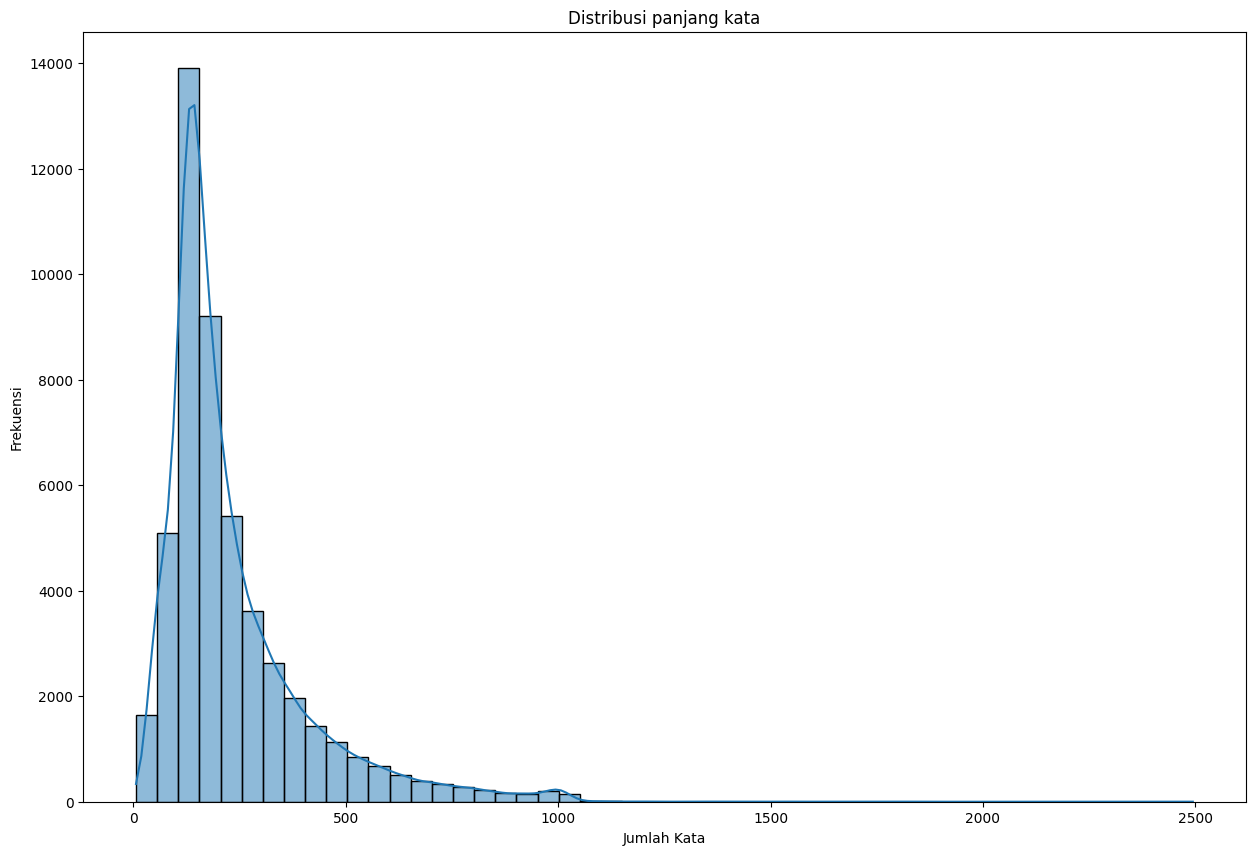

Rata-rata panjang kata: 234 Kata
Kata terpanjang: 2494


In [28]:
print("LABEL ENCODING")

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df[['sentiment', 'label']].head(5))

print("DISTRIBUSI PANJANG KALIMAT BUAT CARI RATA")
df['word_count'] = df['clean_review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(15, 10))
plt.title("Distribusi panjang kata")
sns.histplot(df['word_count'], bins=50, kde=True)
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

print(f"Rata-rata panjang kata: {df['word_count'].mean():.0f} Kata")
print(f"Kata terpanjang: {df['word_count'].max()}")

20
[False, True, False, True, False, True]
